# 04 · ETL — Demographics (Age & Gender)

Auto-classify estimated age and gender across the curated pool. Used to characterise dataset demographics; not a training signal.

In [5]:
from deepface import DeepFace
import glob
from tqdm import tqdm
from PIL import Image
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
pd.set_option('display.max_columns', None)

In [6]:
def extract_attributes(img_array):

    try:
        objs = DeepFace.analyze(
          img_path = img_array,
            actions = ['age', 'gender',],
            anti_spoofing = False,
            detector_backend = 'retinaface',
            expand_percentage = 30,
            enforce_detection = False,
            silent = True

        )

        age = str(objs[0]['age']).title()
        gender = str(objs[0]['dominant_gender']).title()
    
        return age, gender
    except:
        pass

#### VGG_FACE

In [3]:
folder = glob.glob('./VGG_FACE/cropped_and_aligned/*')
progress_bar = tqdm(folder)
contador = 0
final_result = []
for img_file_path in progress_bar:
    file_name = os.path.basename(img_file_path)
    img = Image.open(img_file_path)
    img_array = np.array(img)
    try:
        age, gender = extract_attributes(img_array)

        result = {
            'dataset_name' : 'VGG_FACE',
            'file_name' : file_name,
            'age' : int(age),
            'gender' : gender,
            }
        final_result.append(result)
        if int(age) < 18:
            contador +=1
    except:
        pass
    progress_bar.set_postfix({'under_18' : contador})
final_result_df = pd.DataFrame(final_result)
final_result_df.to_parquet('./VGG_FACE/age_gender_race_vggface.parquet')

100%|██████████| 416/416 [01:41<00:00,  4.12it/s, under_18=0]


In [4]:
final_result_df

,dataset_name,file_name,age,gender
0,VGG_FACE,0242_04.jpg,31,Man
1,VGG_FACE,0110_09.jpg,39,Man
2,VGG_FACE,0565_01.jpg,51,Man
3,VGG_FACE,0101_07.jpg,35,Man
4,VGG_FACE,0041_03.jpg,39,Woman
...,...,...,...,...
411,VGG_FACE,0130_17.jpg,30,Man
412,VGG_FACE,0181_08.jpg,50,Man
413,VGG_FACE,0357_02.jpg,39,Man
414,VGG_FACE,0165_08.jpg,33,Man


#### UTK_FACE

In [7]:
folder = glob.glob('./UTK_FACE/cropped_and_aligned/*')
progress_bar = tqdm(folder)
contador = 0
final_result = []
for img_file_path in progress_bar:
    file_name = os.path.basename(img_file_path)
    img = Image.open(img_file_path)
    img_array = np.array(img)
    try:
        age, gender = extract_attributes(img_array)

        result = {
            'dataset_name' : 'UTK_FACE',
            'file_name' : file_name,
            'age' : int(age),
            'gender' : gender,
            }
        final_result.append(result)
        if int(age) < 18:
            contador +=1
    except:
        pass
    progress_bar.set_postfix({'under_18' : contador})
final_result_df = pd.DataFrame(final_result)
final_result_df.to_parquet('./UTK_FACE/age_gender_race_utkface.parquet')

100%|██████████| 2786/2786 [06:26<00:00,  7.22it/s, under_18=2]


In [8]:
ua = final_result_df[final_result_df['age'] < 18]['file_name'].unique()

In [9]:
for i in ua:
    img_path = f'./UTK_FACE/cropped_and_aligned/{i}'
    os.remove(img_path)


#### FLICKR

In [3]:
folder = glob.glob('./FLICKR/cropped_and_aligned/*')
progress_bar = tqdm(folder)
contador = 0
final_result = []
for img_file_path in progress_bar:
    file_name = os.path.basename(img_file_path)
    img = Image.open(img_file_path)
    img_array = np.array(img)
    try:
        age, gender = extract_attributes(img_array)

        result = {
            'dataset_name' : 'FLICKR',
            'file_name' : file_name,
            'age' : int(age),
            'gender' : gender,
            }
        final_result.append(result)
        if int(age) < 18:
            contador +=1
    except:
        pass
    progress_bar.set_postfix({'under_18' : contador})
final_result_df = pd.DataFrame(final_result)
final_result_df.to_parquet('./FLICKR/age_gender_race_flickr.parquet')

100%|██████████| 15346/15346 [35:22<00:00,  7.23it/s, under_18=1595]


In [17]:
ua = final_result_df[final_result_df['age'] < 18]['file_name'].unique()
ua

array(['41548.png', '06725.png', '51205.png', ..., '21293.png',
       '08438.png', '41251.png'], shape=(1595,), dtype=object)

In [18]:
for i in ua:
    img_path = f'./FLICKR/cropped_and_aligned/{i}'
    os.remove(img_path)


#### CELEBA

In [19]:
import time
time.sleep(4 * 60 * 60)
folder = glob.glob('./CELEBA/cropped_and_aligned/*')
progress_bar = tqdm(folder)
contador = 0
final_result = []
for img_file_path in progress_bar:
    file_name = os.path.basename(img_file_path)
    img = Image.open(img_file_path)
    img_array = np.array(img)
    try:
        age, gender = extract_attributes(img_array)

        result = {
            'dataset_name' : 'CELEBA',
            'file_name' : file_name,
            'age' : int(age),
            'gender' : gender,
            }
        final_result.append(result)
        if int(age) < 18:
            contador +=1
    except:
        pass
    progress_bar.set_postfix({'under_18' : contador})
final_result_df = pd.DataFrame(final_result)
final_result_df.to_parquet('./CELEBA/age_gender_race_celeba.parquet')

100%|██████████| 16855/16855 [28:11<00:00,  9.96it/s, under_18=42]


In [21]:
ua = final_result_df[final_result_df['age'] < 18]['file_name'].unique()
len(ua)

42

In [22]:
for i in ua:
    img_path = f'./CELEBA/cropped_and_aligned/{i}'
    os.remove(img_path)

#### EDA

In [14]:
celeba = pd.read_parquet('./CELEBA/age_gender_race_celeba.parquet')
celeba['gender'].value_counts(normalize = True)

gender
Man      0.556155
Woman    0.443845
Name: proportion, dtype: float64

In [15]:
flickr = pd.read_parquet('./FLICKR/age_gender_race_flickr.parquet')
flickr['gender'].value_counts(normalize = True)

gender
Woman    0.507103
Man      0.492897
Name: proportion, dtype: float64

In [3]:
utkface = pd.read_parquet('./UTK_FACE/age_gender_race_utkface.parquet')
utkface['gender'].value_counts(normalize = True)

,dataset_name,file_name,age,gender
0,UTK_FACE,52_1_0_20170109220548552.jpg,36,Woman
1,UTK_FACE,36_0_1_20170117163449077.jpg,45,Man
2,UTK_FACE,51_0_0_20170104211815983.jpg,52,Man
3,UTK_FACE,34_1_3_20170104220713478.jpg,32,Woman
4,UTK_FACE,40_1_1_20170116235434882.jpg,30,Woman
...,...,...,...,...
2783,UTK_FACE,54_0_3_20170119210131208.jpg,52,Man
2784,UTK_FACE,58_0_0_20170117173244401.jpg,41,Man
2785,UTK_FACE,45_1_0_20170103163617968.jpg,56,Woman
2786,UTK_FACE,26_0_0_20170113210604209.jpg,24,Man


In [17]:
vgg = pd.read_parquet('./VGG_FACE/age_gender_race_vggface.parquet')
vgg['gender'].value_counts(normalize = True)

gender
Man      0.632212
Woman    0.367788
Name: proportion, dtype: float64

In [75]:
df = pd.concat([celeba,flickr,utkface,vgg])
df = df[df['age'] >= 18]

In [76]:
gender_distribution = df['gender'].value_counts(normalize = False).reset_index()
gender_distribution

,gender,count
0,Man,18726
1,Woman,15038


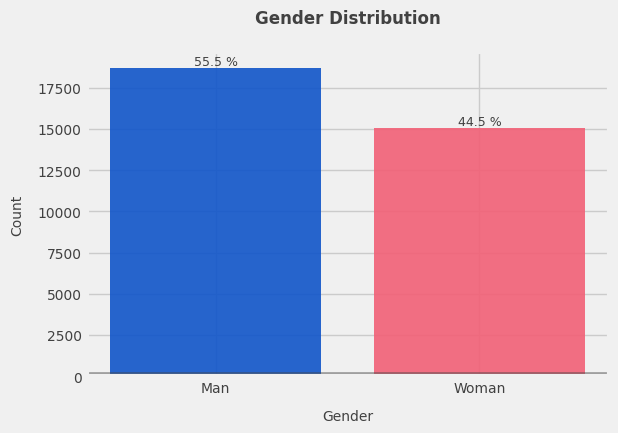

In [79]:
fig, ax = plt.subplots(figsize=(6,4))

bars = ax.bar(
    gender_distribution['gender'],
    gender_distribution['count'],
    color=['#1055C9','#F26076'],
    lw=2,
    alpha=0.9
)


for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{round(height / x["count"].sum(),4) * 100:.1f} %',  
        ha='center',
        va='bottom',
        fontsize=9,
        color='#414141'
    )

# Labels
ax.set_ylabel('Count', fontsize=10, color='#414141', labelpad=10)
ax.set_xlabel('Gender', fontsize=10, color='#414141', labelpad=10)

# Línea horizontal en y=0
ax.axhline(y=0, color='#414141', linewidth=5.5, alpha=.5)

# Ticks
ax.tick_params(axis='y', labelsize=10, colors='#414141')
ax.tick_params(axis='x', labelsize=10, colors='#414141')

ax.set_title('Gender Distribution\n', fontsize = 12, color = '#414141', fontweight = 'bold')
fig.savefig('./figures/gender_distribution.png', dpi = 300, bbox_inches = 'tight')
plt.show()


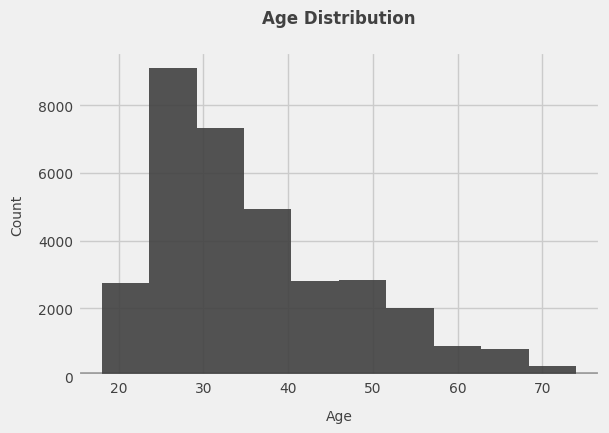

In [80]:
fig, ax = plt.subplots(figsize=(6,4))

counts, bins, patches = ax.hist(
    _['age'],  
    bins=10,
    color='#414141',
    alpha=0.9,
    lw=2
)

# Labels
ax.set_ylabel('Count', fontsize=10, color='#414141', labelpad=10)
ax.set_xlabel('Age', fontsize=10, color='#414141', labelpad=10)

# Línea horizontal en y=0
ax.axhline(y=0, color='#414141', linewidth=5.5, alpha=.5)

# Ticks
ax.tick_params(axis='y', labelsize=10, colors='#414141')
ax.tick_params(axis='x', labelsize=10, colors='#414141')

# Título
ax.set_title(
    'Age Distribution\n',
    fontsize=12,
    color='#414141',
    fontweight='bold'
)

fig.savefig('./figures/age_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
